# STEP 2: Outlier Detection & Classical OLS Diagnostics
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Sikiru Mustapha

---
**Pipeline position:** `Data Cleaning & Splits → Outlier Detection → OLS Diagnostics → VIF Pruning → Regularization → XGBoost/SHAP`

---
This notebook covers boxes 2 and 3. It reads `train_clean.csv` (produced by `01_data_cleaning_splits.ipynb`) and produces `train_no_outliers.csv`, which `03_vif_pruning.ipynb` will build on.

## 2.1 — Mount Google Drive & Load the Cleaned Training Data


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

train = pd.read_csv(f"{PROJECT_FOLDER}/train_clean.csv")
print(f"Loaded {train.shape[0]} rows and {train.shape[1]} columns from Step 1's output.")
train.head()

Mounted at /content/drive
Loaded 155 rows and 28 columns from Step 1's output.


,Company,SFR,Payload (kg),Launch Cost ($M),Price ($/kg),Funding ($M),Launch Class,Orbit Altitude,Tech Type,Country,...,LC_Tourism,OA_LEO,OA_Lunar,OA_Suborbital,TT_Balloon,TT_Other,TT_Plane,TT_Rocket,TT_Spaceplane,Funding_Missing
0,Dark,1,200,5.0,25000,NaN,Small,LEO,"Plane, Rocket",France,...,0,1,0,0,0,0,1,1,0,1
1,TiSPACE,3,390,0.0,0,NaN,Small,LEO,Rocket,Taiwan,...,0,1,0,0,0,0,0,1,0,1
2,Space Engine Systems,4,5500,0.0,0,22.00,Medium,LEO,Spaceplane,Canada,...,0,1,0,0,0,0,0,0,1,0
3,Skyroot Aerospace,5,720,0.0,0,68.00,Small,LEO,Rocket,India,...,0,1,0,0,0,0,0,1,0,0
4,Celestia Aerospace,2,16,0.2,12500,NaN,Small,LEO,"Plane, Rocket",Spain,...,0,1,0,0,0,0,1,1,0,1


## 2.2 — Log-Transform Heavily Skewed Continuous Variables


In [2]:
continuous_cols = ["Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]

# Compute skewness on the TRAINING data only
skew_vals = train[continuous_cols].skew()
print("Skewness of each continuous variable:")
print(skew_vals)

# Apply log1p (ln(x+1)) to any variable with |skew| > 1
log_transformed_cols = []
for col in continuous_cols:
    if abs(skew_vals[col]) > 1:
        train[f"log_{col}"] = np.log1p(train[col])
        log_transformed_cols.append(f"log_{col}")

print(f"\nLog-transformed columns created: {log_transformed_cols}")
print("(All four continuous variables were skewed enough to need this -- expected, given the report's warning about right-skewed launch/payload/funding data.)")

Skewness of each continuous variable:
Payload (kg)        5.507577
Launch Cost ($M)    7.294574
Price ($/kg)        3.360783
Funding_num         8.907725
dtype: float64

Log-transformed columns created: ['log_Payload (kg)', 'log_Launch Cost ($M)', 'log_Price ($/kg)', 'log_Funding_num']
(All four continuous variables were skewed enough to need this -- expected, given the report's warning about right-skewed launch/payload/funding data.)


## 2.3 — Build the Design Matrix & Fit a Baseline OLS Model


In [3]:
# One-hot encode the two single-label categorical columns
dummy_cols = pd.get_dummies(train[["Country_Grouped", "Funding_Type"]], drop_first=True, dtype=int)

# Grab the multi-hot columns already built in Step 1 (LC_, OA_, TT_ prefixes)
multihot_cols = [c for c in train.columns if c.startswith(("LC_", "OA_", "TT_"))]

# Assemble the full predictor matrix
X = pd.concat(
    [train[log_transformed_cols], dummy_cols, train[multihot_cols], train[["Funding_Missing"]]],
    axis=1,
).astype(float)

import statsmodels.api as sm

X = sm.add_constant(X)  # adds the intercept term
y = train["SFR"].astype(float)

print(f"Design matrix shape: {X.shape[0]} rows, {X.shape[1]} predictors (including intercept)")

baseline_model = sm.OLS(y, X).fit()
print(baseline_model.summary())

Design matrix shape: 155 rows, 26 predictors (including intercept)
                            OLS Regression Results                            
Dep. Variable:                    SFR   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.553
Method:                 Least Squares   F-statistic:                     8.950
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           1.02e-17
Time:                        06:12:12   Log-Likelihood:                -286.13
No. Observations:                 155   AIC:                             622.3
Df Residuals:                     130   BIC:                             698.3
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

## 2.4 — Cook's Distance: Find & Remove Influential Outliers


In [4]:
influence = baseline_model.get_influence()
cooks_distances = influence.cooks_distance[0]  # the actual Cook's D values, one per row

n = len(train)
threshold = 4 / n
outlier_mask = cooks_distances > threshold

print(f"Training sample size: {n}")
print(f"Cook's Distance threshold (4/n): {threshold:.4f}")
print(f"Companies flagged as influential outliers: {outlier_mask.sum()} out of {n}")

flagged_companies = train.loc[outlier_mask, "Company"].tolist()
print("\nFlagged companies:")
for company in flagged_companies:
    print(f"  - {company}")

Training sample size: 155
Cook's Distance threshold (4/n): 0.0258
Companies flagged as influential outliers: 15 out of 155

Flagged companies:
  - Orbspace
  - Space Pioneer
  - Black Sky Aerospace
  - Halo Aerospace
  - United Launch Alliance
  - SpaceLoon
  - Swedish Space Corp
  - Stratolaunch
  - Blue Origin
  - Raptor Aerospace
  - Space One (by Canon)
  - Zephalto
  - Forever Space
  - Virgin Orbit/VOX Space
  - SpaceTaxi


In [5]:
# Remove the flagged rows and refit the model to see the impact
X_clean = X.loc[~outlier_mask].reset_index(drop=True)
y_clean = y.loc[~outlier_mask].reset_index(drop=True)
train_no_outliers = train.loc[~outlier_mask].reset_index(drop=True)

clean_model = sm.OLS(y_clean, X_clean).fit()

print(f"R-squared BEFORE removing outliers: {baseline_model.rsquared:.4f}")
print(f"R-squared AFTER removing outliers:  {clean_model.rsquared:.4f}")
print(f"\nRemaining training rows after outlier removal: {len(train_no_outliers)}")

R-squared BEFORE removing outliers: 0.6230
R-squared AFTER removing outliers:  0.7495

Remaining training rows after outlier removal: 140


## 2.5 — Classical OLS Diagnostic Tests


In [6]:
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

# --- 1. Jarque-Bera (normality) ---
jb_stat, jb_pvalue, resid_skew, resid_kurtosis = jarque_bera(clean_model.resid)
print("=== Jarque-Bera Test (Normality of Residuals) ===")
print(f"Statistic: {jb_stat:.3f}, p-value: {jb_pvalue:.4f}")
if jb_pvalue >= 0.05:
    print("PASS: Residuals do not significantly deviate from normality.")
else:
    print("FLAG: Residuals show significant non-normality.")

# --- 2. Breusch-Pagan (homoscedasticity) ---
bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(clean_model.resid, clean_model.model.exog)
print("\n=== Breusch-Pagan Test (Homoscedasticity) ===")
print(f"LM Statistic: {bp_stat:.3f}, p-value: {bp_pvalue:.4f}")
if bp_pvalue >= 0.05:
    print("PASS: No significant heteroscedasticity detected.")
else:
    print("FLAG: Heteroscedasticity detected -- standard errors need correcting (see Section 2.6).")

# --- 3. Durbin-Watson (independence) ---
dw_stat = durbin_watson(clean_model.resid)
print("\n=== Durbin-Watson Test (Independence of Residuals) ===")
print(f"Statistic: {dw_stat:.3f} (values near 2.0 = no autocorrelation)")
if 1.5 <= dw_stat <= 2.5:
    print("PASS: No strong evidence of autocorrelation.")
else:
    print("FLAG: Possible autocorrelation in residuals.")

=== Jarque-Bera Test (Normality of Residuals) ===
Statistic: 4.071, p-value: 0.1306
PASS: Residuals do not significantly deviate from normality.

=== Breusch-Pagan Test (Homoscedasticity) ===
LM Statistic: 42.488, p-value: 0.0159
FLAG: Heteroscedasticity detected -- standard errors need correcting (see Section 2.6).

=== Durbin-Watson Test (Independence of Residuals) ===
Statistic: 1.974 (values near 2.0 = no autocorrelation)
PASS: No strong evidence of autocorrelation.


## 2.6 — Apply Robust Standard Errors (HC3) if Heteroscedasticity Was Detected


In [7]:
if bp_pvalue < 0.05:
    print("Heteroscedasticity was detected -> refitting with HC3 robust standard errors.\n")
    final_diagnostic_model = sm.OLS(y_clean, X_clean).fit(cov_type="HC3")
else:
    print("No heteroscedasticity detected -> standard (non-robust) errors are fine.\n")
    final_diagnostic_model = clean_model

print(final_diagnostic_model.summary())

Heteroscedasticity was detected -> refitting with HC3 robust standard errors.

                            OLS Regression Results                            
Dep. Variable:                    SFR   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     109.3
Date:                Fri, 24 Jul 2026   Prob (F-statistic):           4.15e-68
Time:                        06:12:12   Log-Likelihood:                -217.26
No. Observations:                 140   AIC:                             480.5
Df Residuals:                     117   BIC:                             548.2
Df Model:                          22                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 25, but rank is 23
  warnings.warn('covariance of constraints does not have full '


## 2.7 — Visual Diagnostics


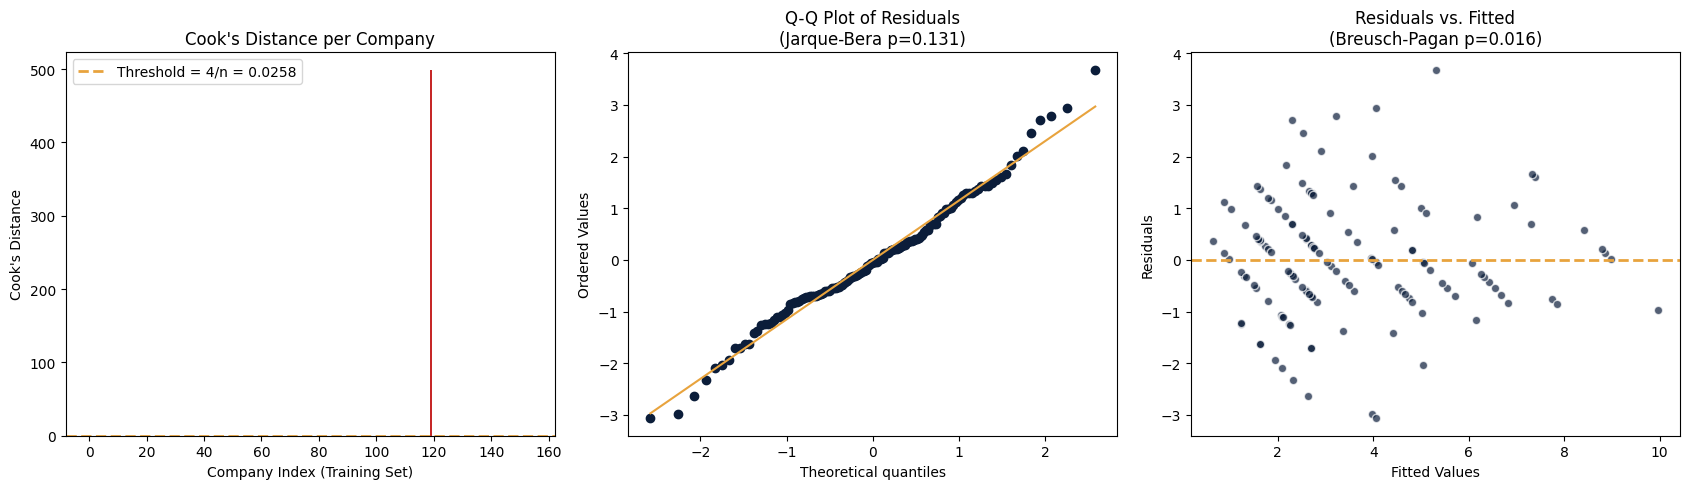

Saved: step2_visual_diagnostics.png
Red bars in the left chart = the 15 companies removed as outliers.


In [8]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Chart 1: Cook's Distance stem plot with threshold line ---
colors_cd = ["#C62828" if flag else "#0B1D3A" for flag in outlier_mask]
axes[0].bar(range(len(cooks_distances)), cooks_distances, color=colors_cd, width=0.8)
axes[0].axhline(threshold, color="#E8A33D", linestyle="--", linewidth=2, label=f"Threshold = 4/n = {threshold:.4f}")
axes[0].set_title("Cook\'s Distance per Company")
axes[0].set_xlabel("Company Index (Training Set)")
axes[0].set_ylabel("Cook\'s Distance")
axes[0].legend()

# --- Chart 2: Q-Q plot of residuals (visual companion to Jarque-Bera) ---
stats.probplot(final_diagnostic_model.resid, dist="norm", plot=axes[1])
axes[1].set_title(f"Q-Q Plot of Residuals\n(Jarque-Bera p={jb_pvalue:.3f})")
axes[1].get_lines()[0].set_markerfacecolor("#0B1D3A")
axes[1].get_lines()[0].set_markeredgecolor("#0B1D3A")
axes[1].get_lines()[1].set_color("#E8A33D")

# --- Chart 3: Residuals vs Fitted (visual companion to Breusch-Pagan) ---
fitted = final_diagnostic_model.fittedvalues
resid = final_diagnostic_model.resid
axes[2].scatter(fitted, resid, color="#0B1D3A", alpha=0.7, edgecolor="white")
axes[2].axhline(0, color="#E8A33D", linestyle="--", linewidth=2)
axes[2].set_title(f"Residuals vs. Fitted\n(Breusch-Pagan p={bp_pvalue:.3f})")
axes[2].set_xlabel("Fitted Values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step2_visual_diagnostics.png", dpi=150)
plt.show()

print("Saved: step2_visual_diagnostics.png")
print("Red bars in the left chart = the 15 companies removed as outliers.")

## 2.8 — Save the Outlier-Cleaned Training Data to Google Drive


In [9]:
train_no_outliers.to_csv(f"{PROJECT_FOLDER}/train_no_outliers.csv", index=False)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - train_no_outliers.csv")
print(f"\nStep 2 complete: {outlier_mask.sum()} outliers removed, OLS diagnostics run, "
      f"{'robust (HC3)' if bp_pvalue < 0.05 else 'standard'} errors used.")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - train_no_outliers.csv

Step 2 complete: 15 outliers removed, OLS diagnostics run, robust (HC3) errors used.
